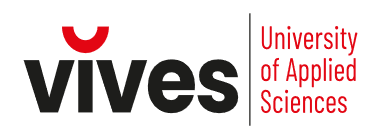<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **POLYNOMIAL REGRESSION: THEORY**

This notebook covers the following topics:

* What are polynomials?
* What is polynomial regression?
* What is underfitting and overfitting?
* How do you determine underfitting and overfitting in regression?
* How can we avoid overfitting?
    * Technique 1: model complexity graph
    * Technique 2: regularization
* Why do we split our dataset?
    * What is the training set?
    * What is the validation set?
    * What is the test set?

## **1. Polynomials**

### Definition

In mathematics, a **polynomial** $p$ in one variable or unknown $x$ is an expression of the form:

> $p(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + ... + a_n x^n$

We can also use the summation sign:

> $p(x) = \sum_{k=0}^{n} a_k x^k$

where $k$ is a natural number, i.e. an integer greater than or equal to 0. As $x^0$ equals 1, the first term $a_0x^0$ reduces to $a_0$.

The constants $a_k$ are the **coefficients**. The highest exponent of the polynomial is the **degree** of the polynomial, in this case $n \neq 0$.

We notice that we get a constant when $n=0$:

> $p(x) = a_0$

and the equation of a line with intercept $a_0$ and slope $a_1$ when $n = 1$:

> $p(x) = a_0 + a_1 x$

In the case of a line we have a **linear equation** because it does not contain powers of $x$.

From the moment the degree of the polynomial is greater than 1, we are dealing with **nonlinear equations**. When $n=2$ we speak of a quadratic polynomial, and when $n=3$ of a cubic polynomial.

### Some examples

Let's plot some polynomials to get a feel for these nonlinear equations:

> $p(x) = 1$

> $p(x) = 2x$

> $p(x) = 4x^2 - 2$

> $p(x) = 8x^3 - 12x$

> $p(x) = 16x^4 - 48x^2 + 12$

> $p(x) = 32x^5 - 160x^3 + 120x$

Applying basic Python, we might as well first define a function that uses a list comprehension to compute $p(x)$ for a given $x$:

In [ ]:
def polynomial(a, x):
    # a is a list containing coefficients a0, a1, a2, ...
    # x is the variable
    return sum([a[k] * x**k for k in range(len(a))])

The last polynomial for $x=2$ then gives:

In [ ]:
polynomial(a=[0, 120, 0, -160, 0, 32], x=2)  # coefficients from smallest to largest exponent!

-16

A better alternative is the `Numpy` function `polyval`:

In [ ]:
import numpy as np

np.polyval(p=[32, 0, -160, 0, 120, 0], x=2)  # coefficients from largest to smallest exponent!

-16

Note! The coefficients here are sorted from largest to smallest power and assigned to argument `p`!

We will now plot the 6 polynomials over the interval $[-2, 2]$:

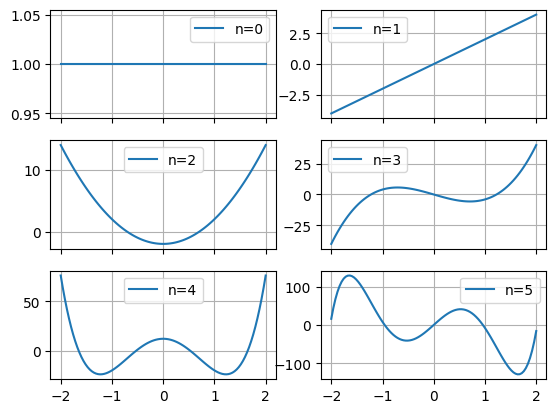

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100

p = [[1], [2, 0], [4, 0, -2], [8, 0, -12, 0] , [16, 0, -48, 0, 12], [32, 0, -160, 0, 120, 0]]
x = np.linspace(-2, 2, 100)
fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True)
ax = ax.flatten()
for i in range(len(p)):
    ax[i].plot(x, np.polyval(p[i], x));
    ax[i].grid();
    ax[i].legend([f'n={i}']);

Some observations:
- $n=0$: we get a horizontal line, because here the polynomial is a constant value $a_0$.
- $n=1$: we get a line, in this example a line through the origin, because the intercept is 0.
- $n \geq 2$: we get curves.
- $n \geq 1$: the maximum number of fluctuations or **oscillations** is equal to $n-1$!

### Multiple variables

Of course, there are also **polynomials in more than 1 variable**. Suppose you have 2 variables $x_1$ and $x_2$, then this could be a polynomial in those 2 variables:

> $p(x_1, x_2) = 5x_1^2x_2 - 10x_1^2 - 3x_2^2 + x_1x_2 - 7x_1 +3x_2 -20$

The degree of this polynomial is 3 because in this case we have to add the exponents of the 2 variables. Here we have a term that contains $x_1^2x_2$, so the degree is 2 + 1 = 3.

## **2. Polynomial regression**

### Explanation

Very often we have a **non-linear relationship** between 2 variables, which prevents us from applying simple linear regression, as in the figure below. In this case we can try to fit our data using a polynomial:

> $y_i = a_0 + a_1 x_i + a_2 x_i^2 + ... + a_n x_i^n = \sum_{k=0}^{n} a_k x_i^k$

Here $x$ is the **independent variable** and thus a **feature** in our dataset, while $y$ is the **dependent variable**, the feature we are predicting, also called **target**. Subscript $i$ refers to the $i$-th data point or sample in the dataset.

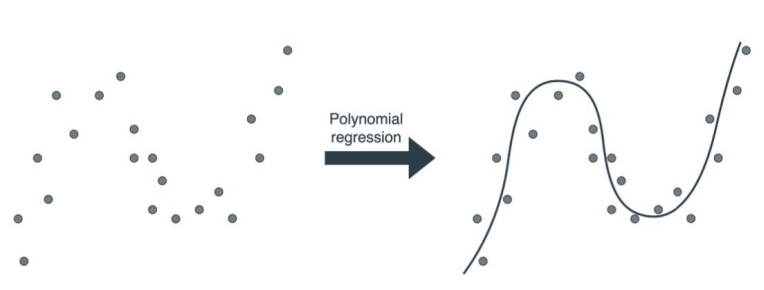

To illustrate the usefulness of polynomial regression in machine learning, we give a fictional and a simple practical example.

Suppose we have two films, "The Matrix" from 1999, and Monty Python's "Life of Brian" from 1979. Variable $x_1$ indicates how long a person watched "The Matrix", variable $x_2$ how long that same person watched "Life of Brian".

Now take a third film, the latest Spider-Man film from 2021. How long will that person watch this film? So, target $y$ is the time that someone watches this new film.

Suppose we apply linear regression where we define the following model:

> $y = 0.5x_1 + 0.3x_2$

We see that the longer people watched film 1, the longer they will also watch the new film. The same is true for film 2. However, if we look at the data, we see that the longer people watch movie 1 and movie 2, the less time they watch movie 3. Since time is positive, we can only solve this problem by adding a nonlinear term to our equation, e.g.

> $y = 0.5x_1 + 0.3x_2 - 0.1x_1x_2$

This extra term now gives us a polynomial in 2 variables of degree 2.

### Example in NumPy

In `NumPy` there is a function `polyfit` which allows us to fit a dataset with 2 variables using a polynomial of a given degree. Let us take the last polynomial from our previous chapter on polynomials again:

> $p(x) = 32x^5 - 160x^3 + 120x$

We generate some data points and add a random measurement error that is normally distributed using the `randn` function from NumPy module `random`:

In [ ]:
# generating the dataset
x = np.linspace(-2, 2, 20);
y = np.polyval([32, 0, -160, 0, 120, 0], x)
np.random.seed(0)  # specify random seed so we always get the same result
y += np.random.randn(len(y))  # error with mean 0 and standard deviation 1

We apply the `polyfit` function to the generated dataset. This function derives the optimal coefficients that give the smallest possible average deviation between target and predictions. In other words, `polyfit` gives us the best fitting curve that is described by a polynomial function. The coefficients of the polynomial are therefore the **parameters** or weights of the regression model that are derived here using **the method of least squares**.

Note that we have to specify the degree of the polynomial via argument `deg`. Because we have to specify that ourselves, the degree of the polynomial function is therefore a **hyperparameter**!

In [ ]:
# fitting the data
a = np.polyfit(x, y, deg=5)
a

array([ 3.20330413e+01, -1.45879667e-01, -1.60346937e+02,  5.89657296e-01,
        1.20358901e+02,  2.68724529e-01])

Due to the measurement error, we do not get exactly the same coefficients, but we do get the best possible fit, because `polyfit` applies the least squares method that minimizes the sum of the squares of the deviations between target and predictions.

Let's plot the result. Note that we are going to use many more points for the predictions here because we want to get a nice smooth curve:

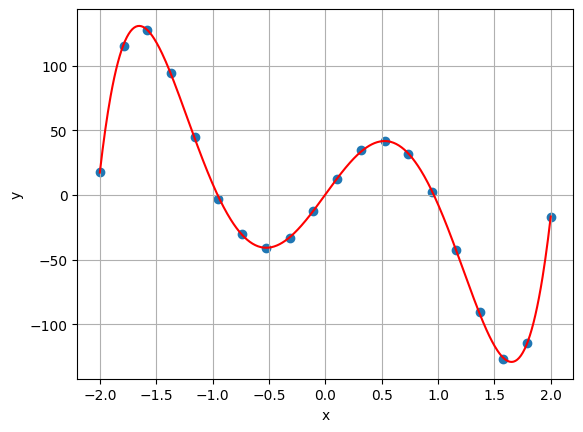

In [ ]:
xcurve = np.linspace(-2, 2, 500)  # generates 500 points in the interval [-2, 2] to get a smooth curve
ycurve = np.polyval(a, xcurve)
plt.scatter(x, y);
plt.plot(xcurve, ycurve, 'r-');
plt.grid()
plt.xlabel('x');
plt.ylabel('y');

Of course, just like with linear regression, we can calculate the Mean Absolute Error (MAE) and the Mean Squared Error (MSE):

In [ ]:
yp = np.polyval(a, x)  # predictions of the data points
print("MAE:", np.round(np.mean(np.abs(y - yp)), 2))
print("MSE:", np.round(np.mean(np.square(y - yp)), 2))

MAE: 0.58
MSE: 0.49


Calculating the coefficient of determination R² or correlation coefficient R is also possible here since polynomial regression is actually a special case of linear regression, as we will also see in the next section.

### Same example in Scikit-Learn

As explained in [YouTube video](https://youtu.be/Q8UfQ_aoCeQ?si=ZXjRRzqLYZx2FZTW), we can also use Scikit-Learn to perform polynomial regression. The method is a bit more complicated, but the advantage is that we can use the many possibilities of Scikit-Learn, such as calculating metrics MAE and MSE.

As already indicated above, polynomial regression is in fact a special case of linear regression. That is why we also use the `LinearRegression` class in Scikit-Learn. But we have to preprocess the data using the `PolynomialFeatures` class. Using the function `make_pipeline` we create a "pipeline" to easily execute these two steps one after the other, while we only call the `fit` method.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

pr = make_pipeline(PolynomialFeatures(degree=5, include_bias=False),  # first the preprocessing (without bias!!)
                   LinearRegression())                                # then the linear regression
pr.fit(X=x[:, np.newaxis], y=y)  # X must be 2D!

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=5, include_bias=False)),
                ('linearregression', LinearRegression())])

Note! The linear regression already takes into account the intercept, also called bias, so we can set `include_bias` to `False` for the `PolynomialFeatures`!

We find the coefficients as follows:

In [ ]:
a2 = pr.steps[1][1].coef_
a2 = np.insert(a2, 0, pr.steps[1][1].intercept_)  # exponents ordered from smallest to largest: add intercept in front!
a2

array([ 2.68724529e-01,  1.20358901e+02,  5.89657296e-01, -1.60346937e+02,
       -1.45879667e-01,  3.20330413e+01])

A bit more complicated, but we still get the same result as with NumPy's `polyfit` function. Note that the coefficients here are sorted from the smallest power to the largest power!

Calculating the metrics MAE and MSE is now easy:

In [ ]:
yp = pr.predict(x[:, np.newaxis])
print("MAE = {:.2f}".format(mean_absolute_error(y_pred=yp, y_true=y)))
print("MSE = {:.2f}".format(mean_squared_error(y_pred=yp, y_true=y)))

MAE = 0.58
MSE = 0.49


And here too we get the same result!

But what does that `PolynomialFeatures` preprocessor actually do? Simple, it expands the dataset with features $x^2$, $x^3$, etc.

In [ ]:
import pandas as pd

degree = 5
x = x.reshape(-1, 1)  # reshape x to table with 1 column
X = np.hstack([x**n for n in range(1, degree+1)])  # create matrix X = [x, x**2, x**3, x**4, x**5]
pd.DataFrame(data=X, columns=['x', 'x^2', 'x^3', 'x^4', 'x^5']).head()  # convert to dataframe

,x,x^2,x^3,x^4,x^5
0,-2.000000,4.000000,-8.000000,16.000000,-32.000000
1,-1.789474,3.202216,-5.730281,10.254188,-18.349599
2,-1.578947,2.493075,-3.936434,6.215422,-9.813824
3,-1.368421,1.872576,-2.562473,3.506542,-4.798425
4,-1.157895,1.340720,-1.552413,1.797531,-2.081351


Now we simply apply linear regression to the expanded matrix `X`:

In [ ]:
model = LinearRegression()
model.fit(X, y)
np.insert(model.coef_, 0, model.intercept_)

array([ 2.68724529e-01,  1.20358901e+02,  5.89657296e-01, -1.60346937e+02,
       -1.45879667e-01,  3.20330413e+01])

As expected, we get the same coefficients, and also the MAE and MSE are the same:

In [ ]:
yp = model.predict(X)
print("MAE = {:.2f}".format(mean_absolute_error(y_pred=yp, y_true=y)))
print("MSE = {:.2f}".format(mean_squared_error(y_pred=yp, y_true=y)))

MAE = 0.58
MSE = 0.49


### An example with real data

We load the file "belgium.gdp.json" with the [Gross Domestic Product](https://en.wikipedia.org/wiki/Gross_domestic_product) (GDP) per inhabitant in US Dollars of Belgium for the period 1960 to 2020:

In [ ]:
import pandas as pd
belgium = pd.read_json("belgium.gdp.json")
belgium = belgium.rename(columns={"jaar": "year", "bbp": "gdp"})  # translate column names to english
belgium.describe()

,year,gdp
count,61.000000,61.000000
mean,1990.000000,21160.826561
std,17.752934,16413.490246
min,1960.000000,1273.691659
25%,1975.000000,6701.377361
50%,1990.000000,20600.375279
75%,2005.000000,36795.976882
max,2020.000000,48106.892916


We create a scatter plot:

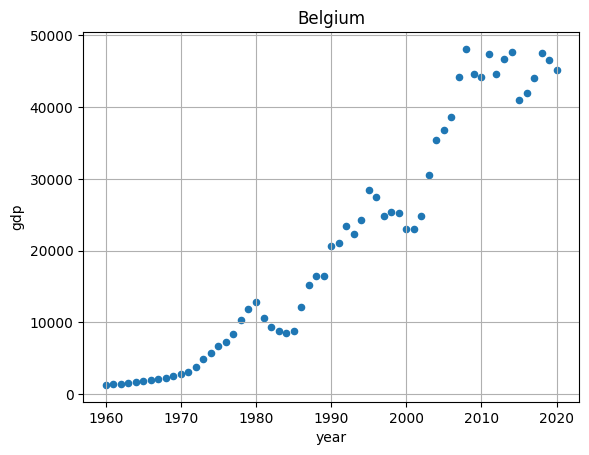

In [ ]:
belgium.plot.scatter(x="year", y="gdp", title="Belgium", grid=True);

Simple linear regression might not do so badly here, but let's see if we can do better by applying polynomial regression. We will go through polynomials of different degrees, and each time calculate the MAE as an evaluation metric to be able to compare the different models afterwards. To make everything run efficiently, we will of course use a loop.

We will also transform our variables, because large values make regression more difficult. For the x-values, we simply subtract the minimum, which is 1960. We transform the y-values ​​logarithmically:

> $z = \log(y)$

with $z$ the logarithmically transformed targets.

In [ ]:
x = belgium.year.values.squeeze() - 1960    # subtract 1960 from x
z = np.log10(belgium.gdp.values.squeeze())  # take logarithm of y

degrees = range(1, 21) # vary degrees from 1 to 20

MAE = []
for deg in degrees:
    a = np.polyfit(x, z, deg)
    zp = np.polyval(a, x)
    MAE.append(np.mean(np.abs(z - zp)))

<ipython-input-38-53dfc9a5d556>:8: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)
<ipython-input-38-53dfc9a5d556>:8: RankWarning: Polyfit may be poorly conditioned
  a = np.polyfit(x, z, deg)


We see that the `polyfit` function gives a warning for the last 2 fits. Without going into the mathematical details, this warning means that the fit is not very reliable.

Now let's plot the result:

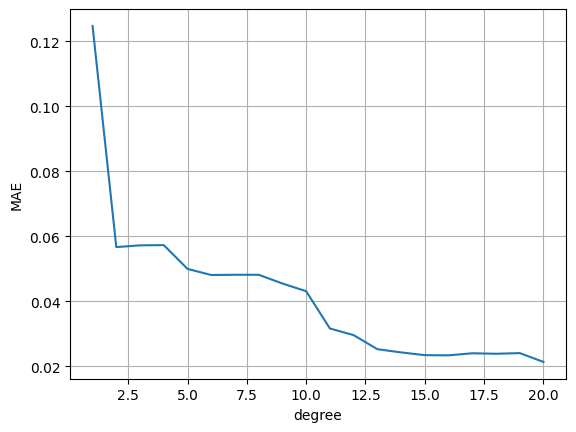

In [ ]:
plt.plot(degrees, MAE);
plt.xlabel("degree");
plt.ylabel("MAE");
plt.grid();

We see that the MAE continues to decrease up to degree 15 (when we take into account the warnings in the last 2 models and do not include them). So we finally choose the regression with a polynomial of degree 15. When calculating the predictions, we must not forget to convert them back:

> $z = \log(y) \iff y = 10^z$

In [ ]:
a = np.polyfit(x, z, deg=15)
zp = np.polyval(a, x)
yp = 10 ** zp  # don't forget to convert the predictions back!

When we add the obtained regression curve to the scatterplot with data, it looks very good!

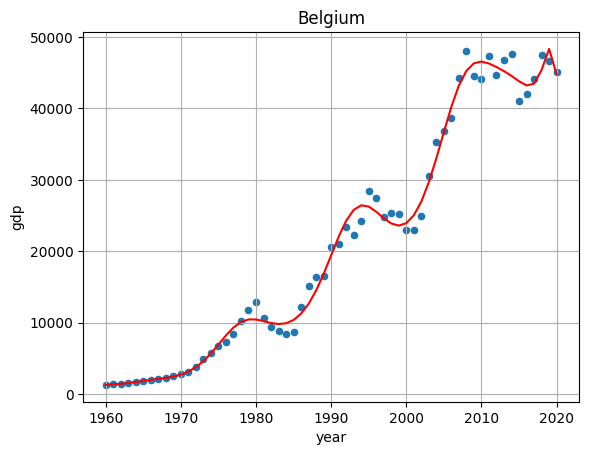

In [ ]:
belgium.plot.scatter(x="year", y="gdp", title="Belgium");
plt.plot(x + 1960, yp, 'r-');  # don't forget to add 1960 to x!
plt.grid();

Great! Now we can predict the GDP of Belgium for the coming years, for example up to 2050:

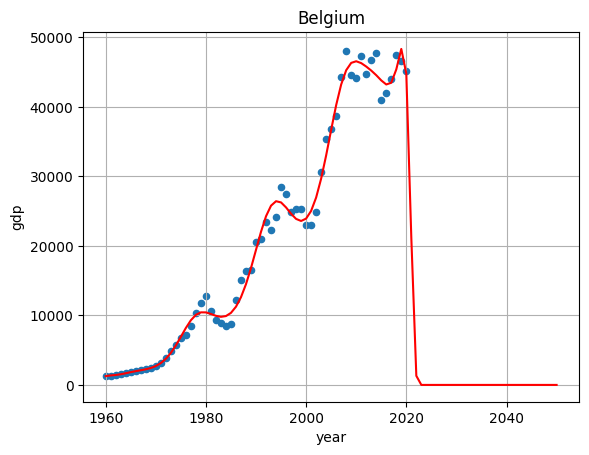

In [ ]:
years = np.arange(1960, 2051)
gdp = 10 ** np.polyval(a, years - 1960) # don't forget to subtract 1960 from the years!

belgium.plot.scatter(x="year", y="gdp", title="Belgium");
plt.plot(years, gdp, 'r-');
plt.grid();

Oops! That doesn't look realistic! What went wrong here?!

Well, we didn't use our model to interpolate, but to **extrapolate**, and as we can see that involves risks, especially when we use high-degree polynomials!

Furthermore, this is a **time series**, a series of data with time as an index. Studying and applying (better) methods to make predictions using time series is a subfield of mathematics called *time series analysis*, and this falls outside the scope of this topic. But we can intuitively sense that when predicting GDP in 2025, we will have to take more account of GDP from recent years than from earlier years. In other words, with time series the *order* of the data points is important, while with other datasets this is often not the case. In linear and polynomial regression, we give each data point equal weight in the prediction, which often leads to poor results for time series because they are ordered.

But even if we use polynomial regression to interpolate data, the approach we have used here is still not a good idea. This has to do with the phenomenon of **overfitting**.

## **3. Underfitting and overfitting**

Since underfitting and overfitting are two fundamental concepts in machine learning and deep learning, this is a **very important chapter** in the course! We will first explain the concepts thoroughly and then provide some techniques you can use to detect and prevent them. Because one thing is for sure: you don't want to deploy models that suffer from underfitting or overfitting!

### Explanation

*A common scenario...*

You develop a machine learning solution, you **train a model** and you use it in your software. During development everything looked good, the model did what it was supposed to do **on the data you had available**, but still something goes wrong: for **new data the predictions are really bad**. What went wrong?! Your model probably suffers from underfitting or overfitting!

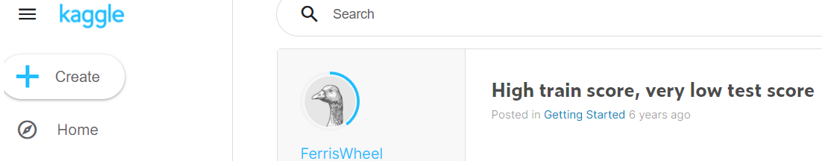

*But what are underfitting and overfitting?*

Compare it to studying for an exam: you can either have studied too little or too much:
* If you have studied too little, your knowledge of the subject matter is too superficial. If you get new exercises or questions, you will not be able to answer them well, because you do not have enough knowledge.
* If you have studied too much, you know almost all the exercises and questions in the course by heart. If you then get such a question or exercise on the exam, you can, without even really understanding the subject matter, give a good answer and score a lot of points! But... you do not do well on new questions, because you do not understand the essence of the course, and you have spent too much time on details.

With Machine Learning you have the same problem:
* **Underfitting** is like studying too little for an exam.
* **Overfitting** is like spending too much time on details, and thus missing the essence of the subject matter.

In machine learning it is crucial that you choose the right type of model, the model that fits your data, and can extract the necessary information from it. You can compare it with the following (absurd) example:

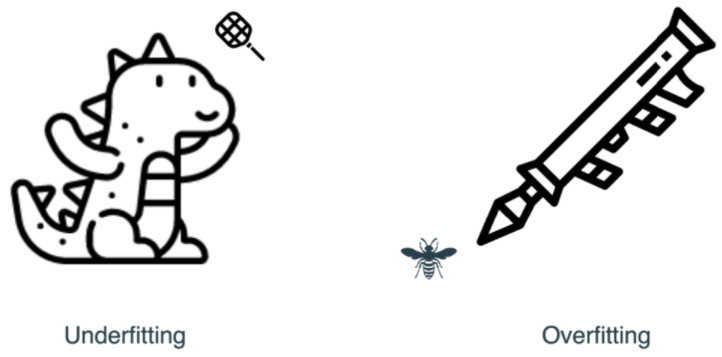

If you try to kill Godzilla with a fly swatter, you won't get there. If you try to kill a mosquito with a bazooka, you'll succeed, but it's bad for the mosquito's immediate environment.
With machine learning, it's exactly the same:

* if your **model is too simple**, it won't be able to capture crucial information in the data and you'll get **underfitting**;
* if your **model is too complex** for the task, you'll learn useless details, and you'll get **overfitting**.

*Don't forget!!!*
> For every task in machine learning, but also in computer science in general: always use the right tool for the task! That is, the right model in machine learning, the right programming language and framework in software development, and so on!

After all, you don't hammer nails into a wooden plank with a saw, do you?

### Regression

What would be the best model for the following data?

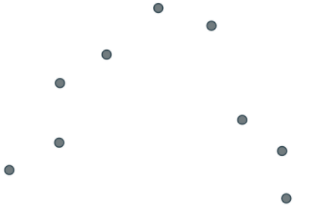

As above, we can also fit this dataset with polynomials of different degrees:

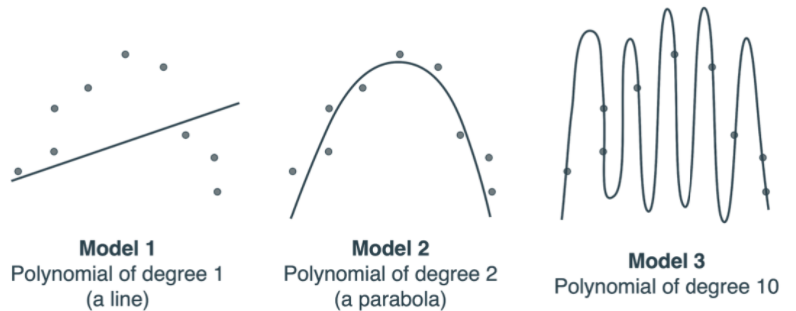

In the figure above, we are testing three models: a linear model and polynomial models of degree 2 and degree 10.

As humans, we can easily visualize the data and the model and see which model is underfitting (model 1), which model is overfitting (model 3), and which model gives a good fit (model 2).

However, it is difficult for a computer to make this visual analysis. We must therefore look for another (numerical) way to make the analysis. In other words, we must find an answer to the question of how we can let an algorithm choose the right model.

The short answer to this question is: **VALIDATE**!

To validate a model you need data, but you are NOT allowed to use that data to train the model. We therefore need to split our dataset into two subsets:
* a **training set** with data that you use to train the model, for example 80% of the available data;
* a **validation set** with data that you use to validate, i.e. to check the model for underfitting and overfitting, for example the remaining 20% ​​of the available data.

Let's apply this to the data from the previous two figures. In the figure below, the dots are the data points from the training set, while the triangles are the data points from the validation set. For each model, we calculate the average error (e.g. the MAE or MSE) for the two data sets:
* The top row shows the error of the three different models on the training set.
* The bottom row shows the error of the three different models on the validation set.

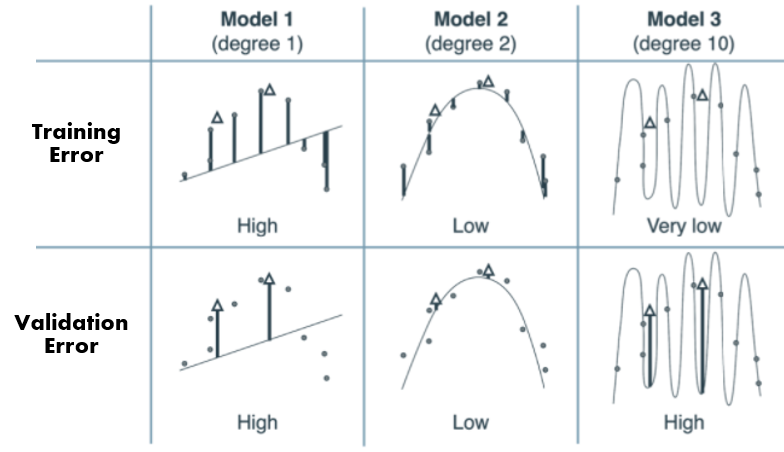

We note the following in the figure:

* Model 1 is the simplest model, and so we can expect underfitting here. If we look at the error, we see that:
  * the error on the training set is large;
  * the error on the validation set is also large.

* Model 3 is the most complex model, and so we can expect overfitting here. If we look at the error, we see that:
  * the error on the training set is very low;
  * the error on the validation set is *high*!

* Model 2, on the other hand, is neither too simple nor too complex. If we look at the error, we see that:
  * the error on the training set is low;
  * the error on the validation set is also low!

**We can conclude the following:**

* In the case of **underfitting**:
  * The model is too simple for the dataset, too generic, in other words it overgeneralizes
  * The model will therefore not perform well on data from the validation set...

* In the case of **overfitting**:
  * The model is too complex for the dataset, too specific, in other words it does not generalize enough
  * The model will therefore not perform well on data from the validation set...

* So we are looking for a model that does not suffer from underfitting or overfitting:
  * The model is not too generic and not too specific.
  * The model will therefore also perform well on data from the validation set!

As shown in the graph below, we need to find a balance between **optimization**, i.e. letting the model fit the data as well as possible during the training phase, and **generalization**, i.e. letting the model also make reliable predictions on new data during the inference phase (see below).

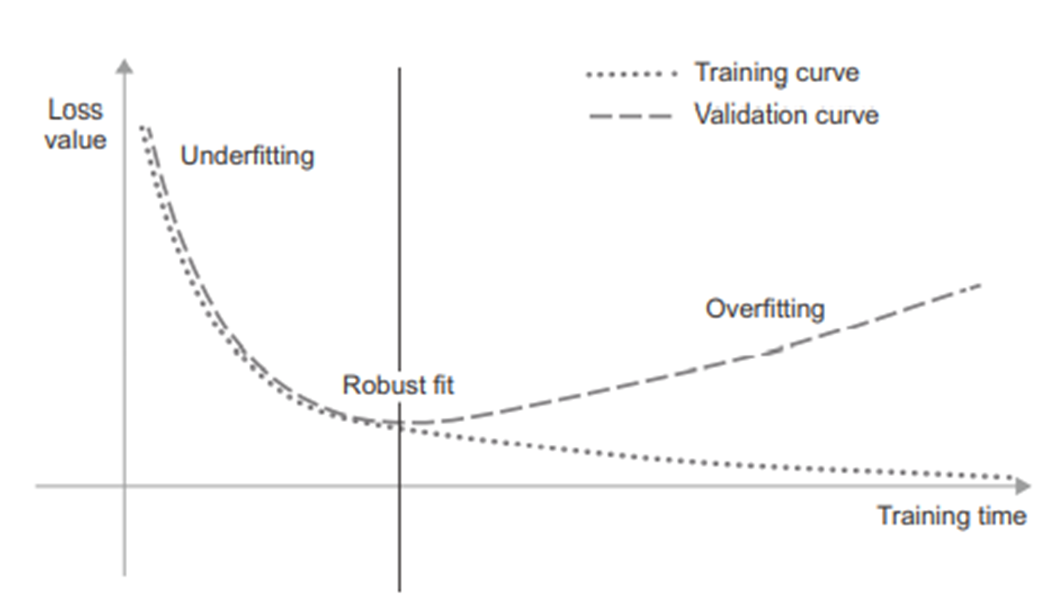

In more statistical terms, we talk about the **bias-variance tradeoff**. As clearly explained in this [video by StatQuest](https://youtu.be/EuBBz3bI-aA?si=OsL2_ITGfZ0xrs9d), a model that is too simple has a high *bias* error. In other words, incorrect assumptions were made about the model. Think of using linear regression to model a non-linear relationship between variables. A model that is too complex will have a small bias error.

The *variance* indicates how sensitive a model is to small fluctuations in the data, which we call **noise**. A simple model has a small variance, a complex model a large variance. The figure below clarifies the concepts using an analogy with archery or playing darts.

Finally, the *tradeoff* refers to the compromise we have to find between bias and variance, because underfitting results in a high bias and small variance model, and overfitting results in a low bias and large variance model.

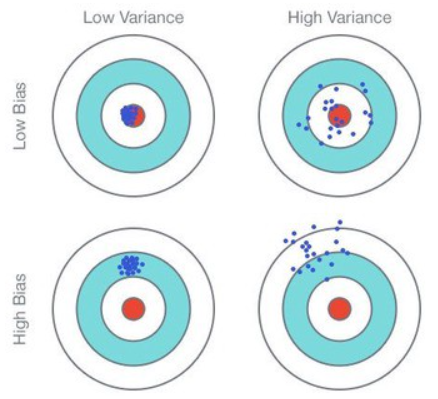

Fortunately, in machine learning there are **several techniques** available **to overcome overfitting**. In this topic we will discuss two for regression: the *model complexity graph* and *regularization*.

### Technique 1: Model Complexity Graph

The first and simplest technique is actually a small extension of what we did above. We are going to train different polynomial models, but this time we calculate the error for the training set and for the validation set. These errors are plotted again in a graph: the model complexity graph. This gives us two curves: one for the training set and one for the validation set. The best model is then the model that gives the smallest error for the validation set.

When deciding which degree to use in a model, we have to try different possibilities. To decide which model is best, we look at the training error (error on the training set) and the validation error (error on the validation set). We don't want overfitting, so as we indicated in the previous section, we aim for a small training error and a small validation error. As soon as the validation error stops decreasing while the training error continues to decrease, we are dealing with overfitting. We see this nicely depicted in the figure below:

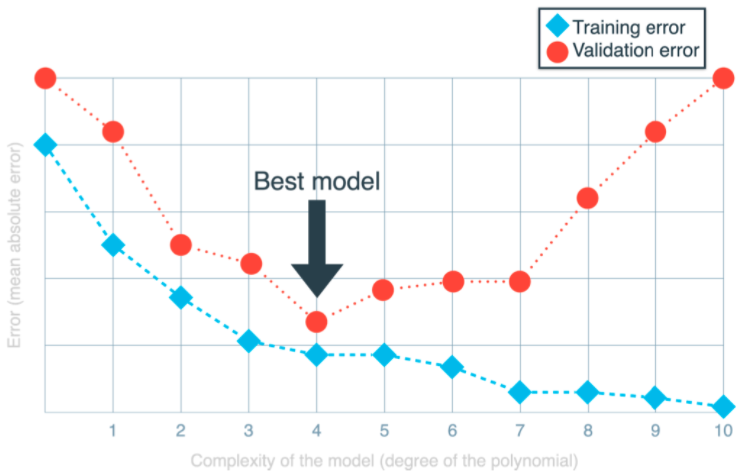

The figure above is an example of a **model complexity graph**. On the X-axis we let the degree of the regression model increase, on the Y-axis is the value of the error function, for example the MAE or MSE. The degree of the regression model is indeed a measure of the complexity of the model, because the higher the degree, the more parameters - in this case coefficients - the model contains.

Up to degree 4 both the training error and the validation error decrease. From degree 4 we clearly see that the validation error increases again while the training error continues to decrease. The model with degree 4 will therefore be the best model. Every model complexity graph will approximately take this form and can therefore be used to decide which model we should choose.

#### *Example*

Let's illustrate this with the polynomial we already fitted above:

> $p(x) = 32x^5 - 160x^3 + 120x$

We generate 100 data points and again add a random measurement error that is normally distributed, but this time we make the error larger by taking a standard deviation of 10 instead of 1:

In [ ]:
x = np.linspace(-2, 2, 100);
y = np.polyval([32, 0, -160, 0, 120, 0], x)

np.random.seed(0)  # specify random seed so we always get the same result
y += np.random.randn(len(y)) * 10  # error with mean 0 and standard deviation 10

This time we split the dataset into a training and validation set. Of course, we have to do this splitting randomly. We do this by shuffling the indices and then using half of the indices for the validation set and the other half for the training set:

In [ ]:
idx = np.arange(len(x))  # the indices of the data points
np.random.shuffle(idx)   # shuffle the indices
n = len(idx) // 2        # divide the dataset into two equal parts - be careful! use integer division!
ival = idx[:n]           # the indices of the data points in the validation set
itrain = idx[n:]         # the indices of the data points in the training set

Let's first plot the split dataset for verification:

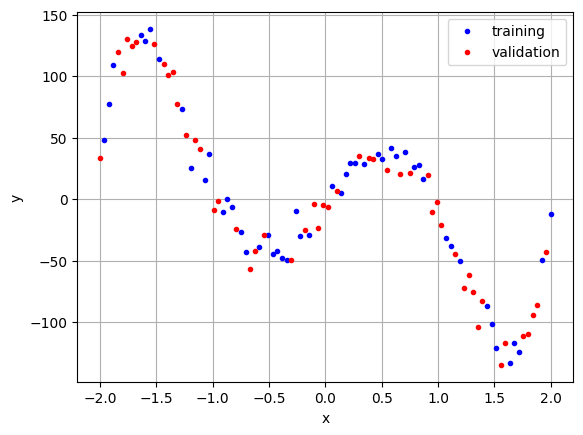

In [ ]:
plt.plot(x[itrain], y[itrain], 'b.', x[ival], y[ival], 'r.');
plt.xlabel('x');
plt.ylabel('y');
plt.grid();
plt.legend(['training', 'validation']);

The data points are nicely distributed over training and validation set. Let us now train different polynomial models where the degree varies from 1 to 20, as we did above. But this time we only derive the coefficients based on the training set! Then we calculate the predictions for all data points. Finally, we calculate the MAE separately for training and validation set:

In [ ]:
degrees = range(1, 21) # the degree of the polynomials

MAE_train = [] # initialize list for MAE of training data
MAE_val = [] # initialize list for MAE of validation data

for n in degrees:
    a = np.polyfit(x[itrain], y[itrain], deg=n) # fit only the training set!
    yp = np.polyval(a, x) # predictions of all data points
    MAE_train.append(np.mean(np.abs(yp[itrain] - y[itrain]))) # MAE of training data
    MAE_val.append(np.mean(np.abs(yp[ival] - y[ival]))) # MAE of validation data

Now all that remains is to plot the model complexity graph:

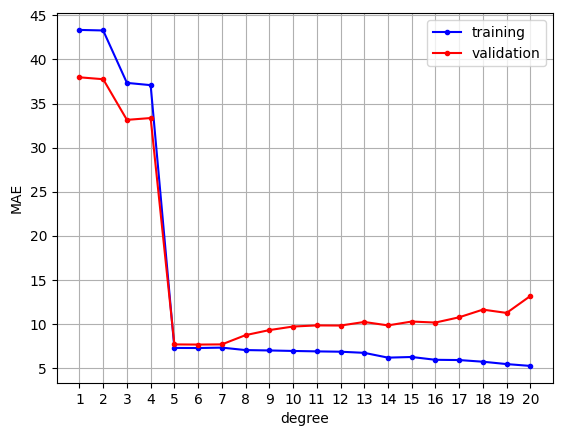

In [ ]:
plt.plot(degrees, MAE_train, 'b.-', degrees, MAE_val, 'r.-')
plt.xticks(degrees);  # set ticks and corresponding labels of x-axis
plt.xlabel('degree');
plt.ylabel('MAE');
plt.grid();
plt.legend(['training', 'validation']);

The shape deviates somewhat from the typical graph we discussed in the figure above, but we can clearly see that the MAE of the training set continues to decrease, while that of the validation set starts to increase again from degree 7. We also see a plateau from degree 5 to 7, and therefore we take a degree 5 polynomial as our final model, because it contains fewer parameters. We run the regression again, this time on the full dataset:

In [ ]:
a = np.polyfit(x, y, deg=5)
a

array([ 3.12013880e+01,  1.00197087e-01, -1.56282920e+02,  2.88714278e+00,
        1.15854095e+02, -3.66288352e+00])

Due to the large error, the coefficients deviate somewhat from the "true" coefficients, but the MAE is, as expected, within the standard deviation of the measurement error:

In [ ]:
yp = np.polyval(a, x)
MAE = np.mean(np.abs(y - yp))
MAE

7.303895740027681

And if we plot the regression curve, we see a very good fit:

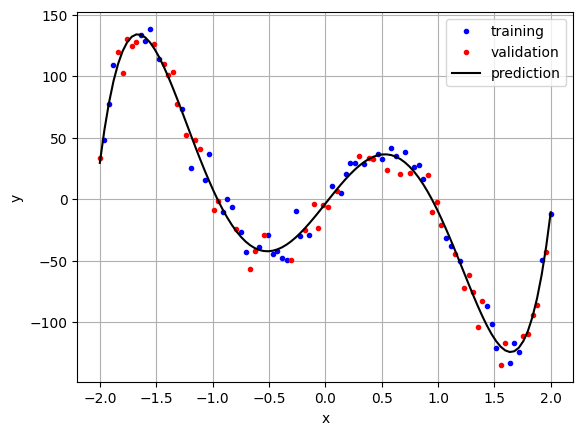

In [ ]:
xcurve = np.linspace(-2, 2, 100)
ycurve = np.polyval(a, xcurve)
plt.plot(x[itrain], y[itrain], 'b.', x[ival], y[ival], 'r.', xcurve, ycurve, 'k-');
plt.xlabel('x');
plt.ylabel('y');
plt.grid();
plt.legend(['training', 'validation', 'prediction']);

Based on the model complexity graph, we are able to determine the degree of the polynomial function that we used to generate the data!

#### *Overfitting in other machine learning models*

When training **neural networks** we will apply a similar technique, but in this case we will look at the error of the training and validation set as a function of the number of epochs. From a certain number of epochs onwards, overfitting will also occur, and then we must of course stop training, as shown in the figure below. We see that the graph plotting the loss or error as a function of the number of iterations or epochs, indeed has the same shape as the model complexity graph:

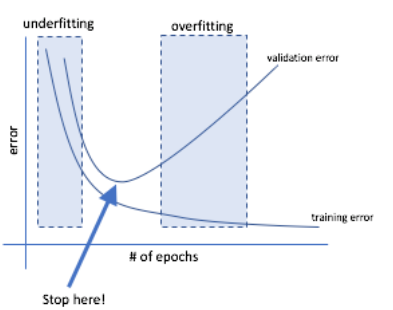

For **decision trees** we can also draw up such a curve. When a decision tree is used for classification, we can, for example, plot the accuracy of the predictions against the size of the decision tree. The greater the accuracy, the smaller the error, and the larger the decision tree, the more complex the model. Overfitting occurs when the accuracy on the validation set no longer increases while the accuracy on the training set continues to increase. The figure below shows how we can counteract the effect of overfitting by "pruning" the decision tree, which involves reducing the size of the tree by removing branches that have little importance or predictive power:

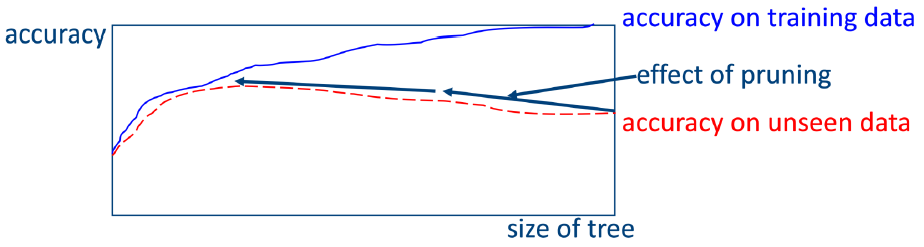

We get a similar graph to the model complexity graph, but mirrored, because here we are looking at accuracy instead of error, and the former increases as the latter decreases.

### Technique 2: Regularization

The problem with building a model complexity graph is that we always have to train past the point where overfitting occurs. The technique discussed in this section attempts to prevent overfitting while training only one model.

Training multiple models and choosing the "best" one - i.e. the model with the "best" predictions without underfitting or overfitting - can take up a lot of unnecessary computing power. In that respect, it would be better if we only had to train one model. To do that, we have to make sure during training that a model that is possibly too complex will not suffer from overfitting.

This is where **regularization** comes in: during training we try to make sure that both the performance on the data is good and the model remains *simple*.

We remember from the topic on linear regression that in Gradient Descent we minimize the loss or **error function**. A function that we minimize with an optimizer like Gradient Descent is generally called an *objective function* or *cost function*.

However, the error function only looks at the performance of the model. It is a measure of how well it makes predictions. However, we also want to take the complexity of the model into account. So we need another function that measures how complicated our model is: the **complexity function**. And that function must also be minimized so that the model remains as simple as possible.

That is why we are not only going to minimize the error function, but a combination of error and complexity function. This way we arrive at a new objective or cost function that must be minimized:

> `new_cost_function = performance_cost_function + complexity_cost_function`

The question now is: how do we measure the complexity of a model, or what does the complexity function look like?

#### *The Roofer Analogy*

To answer that question, let's first look at overfitting in a different way using an analogy. Suppose you need to repair your roof because it has a leak. You have three options:
* patch it up with duct tape;
* lay new roof tiles;
* waterproof it with titanium.

It is clear to a human what is underfitting and what is overfitting! But how can we express this using a number? In other words, how can a computer make the distinction?

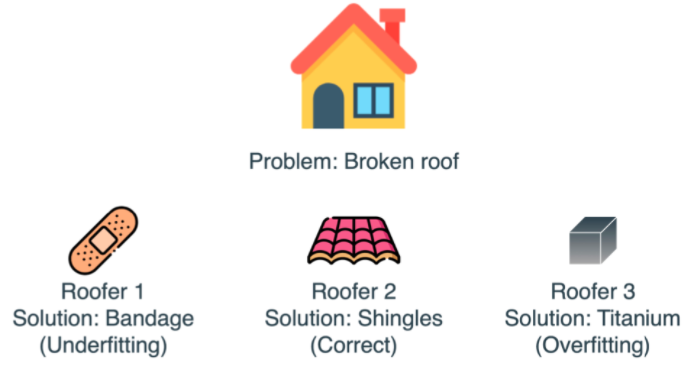

We must try to express both the performance and the complexity of the solution with numerical values. For the performance or effectiveness of the chosen solution, we can measure how much water still leaks after applying the solution:
* solution 1: 1000 ml water
* solution 2: 1 ml water
* solution 3: 0 ml water

The complexity or intricacy can be measured by looking at the cost of the chosen solution:
* solution 1: € 1
* solution 2: € 100
* solution 3: € 100,000

Which solution is now the most suitable to repair the leaking roof? Clearly solution 2, because if we add performance and complexity, we only get 101:
* solution 1: 1001
* solution 2: 101
* solution 3: 100,000

*A machine learning example*

Now let's look at a simplified machine learning problem. We resume the example of recommending a movie based on previous movies that have been watched. We assume that there are 10 movies $M_1$, $M_2$, ..., $M_{10}$ in our system. We now want to make predictions for a new movie $M_{11}$. We use a linear regression model for this:

> $y = w_0 + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + w_5x_5 + w_6x_6 + w_7x_7 + w_8x_8 + w_9x_9 + w_{10}x_{10}$

with:

* $y$ the predicted time the user spends on movie 11;
* $x_i$ the time the user spent on movie $i$;
* $w_i$ the weight in the model corresponding to feature $x_i$;
* $w_0$ the bias or intercept.

Suppose we have two models with which we can make the prediction:

- Model 1:

> $y = 4 + 2x_3 + 1.4x_7 - 0.5x_9$

- Model 2:

> $y = 8 + 22x_1 - 103x_2 - 14x_3 + 109x_4 - 93x_5 + 203x_6 + 87x_7 - 55x_8 + 378x_9 - 25x_{10}$

What is the most complex model?

That is clearly Model 2, because:

* We see that the second model uses a lot of parameters, because no weight $w_i$ is zero.
* We also see large weights. For example, it is very unlikely that the time a user spends on the new movie depends on -103 times the time spent on $M_2$.

However, Model 1 also gives us a lot of information:
* If a user spends a lot of time on $M_3$ and $M_7$, then the user will probably find $M_{11}$ very interesting, because the weights $w_3$ and $w_7$ are positive.
* If a user spends a lot of time on $M_9$ with negative weight $w_9$, then the interest in $M_{11}$ will probably be low.

When it comes to simplicity, we prefer Model 1. But Model 2 will probably have a smaller error on the training set and so Model 2 will be chosen if we only look at performance. So we need to somehow ensure that the complexity of Model 2 is taken into account when minimizing the error function.

#### *$L_1$- and $L_2$-norm*

The previous example gives a good hint on what the complexity function can be based on. After all, a complex model contains many parameters (or weights) and they are quite large!

Two functions or formulas are possible:
* **the $L_1$-norm**: the sum of the absolute values ​​of the weights;
* **the $L_2$-norm**: the sum of the squares of the weights.

For Model 1 and Model 2 from the previous example, we calculate the norms as follows:

- Model 1
  * $L_1$-norm: $|2| + |1.4| + |-0.5| = 3.9$
  * $L_2$-norm: $(2)^2 + (1.4)^2 + (-0.5)^2 = 6.21$

- Model 2

  * $L_1$-norm: $|22| + |-103| + |-14| + |109| + |-93| + |203| + |87| + |-55| + |378| + |-25| = 1089$
  * $L_2$-norm: $(22)^2 + (-103)^2 + (-14)^2 + (109)^2 + (-93)^2 + (203)^2 + (87)^2 + (-55)^2 + (378)^2 + (-25)^2 = 227131$

Note that the bias $w_0$ is *not* taken into account! We see that both the $L_1$-norm and the $L_2$-norm of Model 2 are higher than those of Model 1, from which we can indeed conclude that Model 2 is more complex than Model 1.

#### *Lasso and Ridge Regularization*

We can now add the $L_1$ and $L_2$ norms to the cost function in linear and polynomial regression:
* If we use the $L_1$ norm, we call it **Lasso regularization**:
> ```lasso_regression_cost = regression_cost + L1_norm```
* If we use the $L_2$ norm, we call it **Ridge regularization** (or Thikonov regularization):
> ```ridge_regression_cost = regression_cost + L2_norm```

Applying the $L_1$ norm and/or the $L_2$ norm to control the complexity of the model is called **regularization**. The $L_1$ and $L_2$ norms are the complexity cost or the **regularization cost**.

However, we must be careful not to regularize too much. To be able to arrange that, we are going to introduce a new hyperparameter $\lambda$, **the regularization parameter**, with which we can determine how much of the complexity cost or regularization cost we include in the total cost.

Some examples:
* $\lambda = 0$: the regularization cost is not included;
* $\lambda = 0.01$ or $\lambda = 0.1$: part of the regularization cost is included;
* $\lambda = 10$ or $\lambda = 100$: a multiple of the regularization cost is included.

Regularization parameter $\lambda$ influences the operation, performance and quality of a model, just like the learning rate. It is also a *hyperparameter*, because it is specified by the user. An optimal value must be found for each combination of a model and a dataset. This is usually done through experiments: trying out multiple values ​​and seeing which value works best.

Lasso and Ridge regularization have different effects on the coefficients. In practice, we often see the following effect:

* Lasso regression causes coefficients to become small and some even zero, which means the model will have fewer coefficients.

* Ridge regression causes coefficients to become small, but they rarely become zero.

Depending on the effect we want to achieve, we can choose Lasso regression or Ridge regression. For example, in a recommender system, where we know from experience that not every film has an effect on another film, we will be more inclined to choose Lasso regression, while in image recognition, where we do want every pixel to be taken into account, we will be more inclined to choose Ridge regression, because not every pixel is equally important, but every pixel does count! But we can also combine the two, as the **Elastic Net** regression algorithm does.

There are other regularization techniques, such as adding a **drop-out** layer to an artificial neural network. Such a layer then sets a predefined number of randomly selected weights in the network to zero during training. For large models with very many weights, this is even a more effective technique than applying the $L_1$ or $L_2$ norm, which are more suitable for smaller models. Drop-out layers are discussed in detail in the Deep Learning course.

#### *A code example*

In this example, we will apply Lasso and Ridge regression to the data we generated above based on the following polynomial:

> $p(x) = 32x^5 - 160x^3 + 120x$

To be sure, we will generate the 100 data points again, and as before, we will add a random measurement error that is normally distributed with a mean of 0 and a standard deviation of 10:

In [ ]:
x = np.linspace(-2, 2, 100);
y = np.polyval([32, 0, -160, 0, 120, 0], x)

np.random.seed(2022)  # specify random seed so we always get the same result
y += np.random.randn(len(y)) * 10  # add random error with mean 0 and standard deviation 10

We fit the data with a polynomial of degree 10, but we apply regularization to prevent overfitting. We do this using the Scikit-Learn classes `Lasso` and `Ridge`. The code is the same as for polynomial regression, but we need to replace the `LinearRegression` object in the last step of the pipeline with a `Lasso` or `Ridge` object:

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degree = 10 # polynomial of degree 10
lasso = make_pipeline(PolynomialFeatures(degree, include_bias=False), # bias not needed!
                      Lasso(alpha= 0.1, tol=0.1))  # Lasso regression
lasso.fit(x[:, np.newaxis], y);

ridge = make_pipeline(PolynomialFeatures(degree, include_bias=False), # bias not needed!
                      Ridge(alpha=0.1, tol=0.1))  # Ridge regression
ridge.fit(x[:, np.newaxis], y);

A bit confusing, but input parameter `alpha` is here the regularization parameter $\lambda$. Input argument `tol` is the stopping criterion for the iterative solver. By default this is `1e-4`, but we increased it here, because otherwise we get a warning that the solver does not converge within the given "tolerance".

Let's have a look at the coefficients, which are sorted here from smallest to largest power:

In [ ]:
print('Lasso:')
a_lasso = np.hstack((lasso.steps[1][1].intercept_, lasso.steps[1][1].coef_))
print(a_lasso)

print('Ridge:')
a_ridge = np.hstack((ridge.steps[1][1].intercept_, ridge.steps[1][1].coef_))
print(a_ridge)

Lasso:
[ 1.03119392e-02 -2.64149446e+00 -9.80632662e-01 -3.45361763e+01
  3.59279416e-01  1.07316748e+00  6.48949067e-02  7.79397078e-01
 -4.47433063e-03  1.97836980e-01 -4.34379437e-03]
Ridge:
[  0.43507875  94.46339179   0.70060854 -93.24239903   0.71899273
 -21.12539185  -5.02312781  16.50091183   2.88118526  -1.7614829
  -0.42655585]


Lasso regression does indeed give weights that approach zero, but still, at first sight, the coefficients of Ridge regression seem to match those of the polynomial we used to generate the data better. And that is also confirmed by the plot:

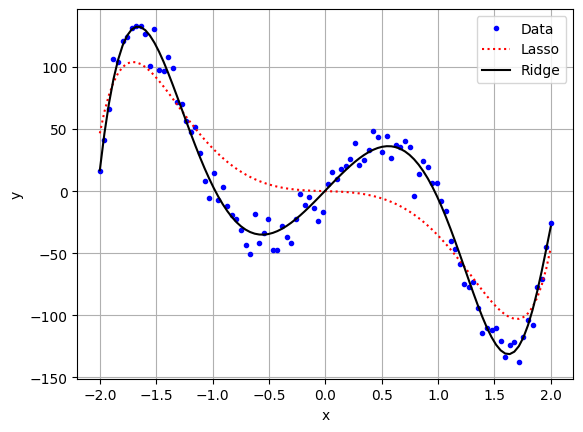

In [ ]:
x_curve = np.linspace(-2, 2, 100)
y_lasso = np.polyval(a_lasso[::-1], x_curve) # reverse coefficients for polyval!
y_ridge = np.polyval(a_ridge[::-1], x_curve) # reverse coefficients for polyval!

plt.plot(x, y, 'b.',
         x_curve, y_lasso, 'r:',
         x_curve, y_ridge, 'k-');
plt.xlabel('x');
plt.ylabel('y');
plt.grid();
plt.legend(['Data', 'Lasso', 'Ridge']);

We do see that in both cases overfitting has been effectively avoided, even though we have performed a regression with a polynomial of degree 10! The Lasso regression curve now even suffers from underfitting, while Ridge's seems to be a good fit. However, that does not mean that Ridge regression will always be better than Lasso. We must always investigate this carefully, with different values for the regularization parameter. And in order to be able to properly evaluate and compare all these different models, we must also split our dataset into a training and a validation set. In principle, we should always do this, and according to the machine learning best practices, we should even do a final evaluation with a test dataset!

## **4. Train, validate, test**

Splitting a dataset into training, validation and test set is a best practice in machine learning and deep learning. So this is also **a very important chapter**!

### Why 3 datasets?

In machine learning, we distinguish between 3 types of datasets:

* The **TRAINING SET** is used by the **algorithm** to train the model, which means that the **parameters** are optimized with this set.
* The **VALIDATION SET** is used by the **user** to fine-tune **hyperparameters**. For example, think of finding the optimal degree in polynomial regression. Using the validation set, one detects **overfitting**, and by fine-tuning the hyperparameters one tries to avoid this overfitting.
* The **TEST SET** is only used by the **user** for the **final evaluation** of the ultimately selected model.

But why is this final evaluation necessary? Take the example of the model complexity graph. The polynomial regression is performed on the training set, which means that the coefficients - which we also call the model parameters - are optimized by the algorithm using this dataset. The algorithm therefore uses the information from the training set to find the optimal coefficients.

We have not used the validation set to optimize those parameters, but we do decide on the basis of this dataset which model we will ultimately use. In our example, we choose the degree of the polynomial using the validation dataset. We therefore also use information from the validation set to select a final model and therefore information from this set "leaks" into our model. We call this **information leaks**, and we actually want to avoid them as much as possible. In fact, it is even possible to overfit a model on the validation set!

That is why we also want to evaluate our selected model on data that we have not yet used. Hence a third dataset, the test set, which is used for the final evaluation on unseen data. Only when this final evaluation is successful, our choice is final. We then train the model one last time on the full dataset, and that final model can finally go into production to make predictions with completely new data. That last training completes the **training phase**, and applying the model to new data in a production environment is called the **inference phase**. The final model is then also called the *inference model*.

### Simple hold-out validation

Moral of the story: we need to split our dataset into 3 parts, as shown below. First, we set aside a (smaller) part of the dataset for testing. The remaining part we use for training, but as we know, we also need to use a (smaller) part of it for validation. For example, we could split the dataset as follows:
* 60-20-20: 60% of the data for training, 20% for validation, and 20% for testing
* 80-10-10: 80% of the data for training, 10% for validation, and 10% for testing

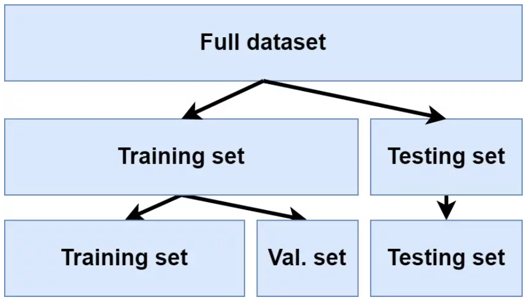

If we split the dataset as in the figure above, and in particular use one (smaller) part of the training set for validation, we speak of **simple hold-out validation**. You can use the Scikit-Learn function `train_test_split()` for this.

This way of working is fine if we have a lot of data. But what if we only have a limited dataset available?

### K-fold cross-validation

**Cross-validation** can provide a solution for small datasets. In this case, we split the training set into K equal groups or *folds*. We therefore also speak of *K-fold cross-validation*.

The idea is that we repeat the training K times, so that each fold serves as a validation set once, while the other folds together form the training set. After each of the K iterations or *splits*, we calculate the performance score, e.g. the MAE or MSE, for both the training set and the validation set.

After performing all the splits, we can then calculate the average of all scores for training and validation, in order to ultimately choose the most performing model based on those average scores.

The figure below illustrates the principle:

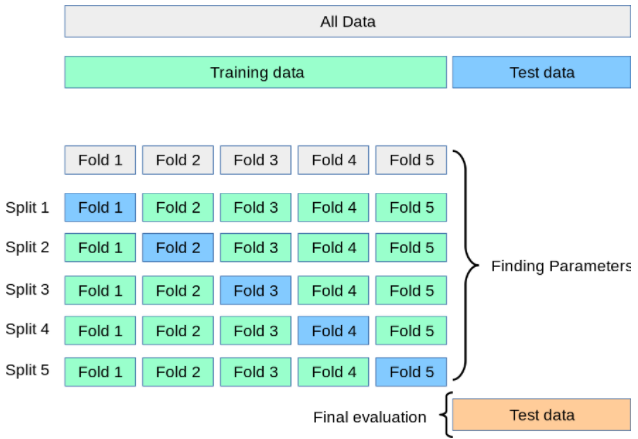

We will go into this in more depth later in the course, and certainly in the Deep Learning course.

### Golden rule

To conclude, we would like to give you **the following very important rule**:

> NEVER USE THE TEST DATA TO TRAIN THE MODEL!
>
> TEST DATA MUST ONLY BE USED FOR TESTING!

For example, if you are going to standardize the dataset using mean and standard deviation, then you may only calculate those two statistics based on the training set! But you do use them to normalize both the training and test set:

```python
mu = mean(X_train) # mean of training data!
sigma = std(X_train) # standard deviation of training data!

X_train = (X_train - mu) / sigma # normalize training data
X_test = (X_test - mu) / sigma # normalize test data

```

So you have to split up your dataset before you start normalizing!

---
---

## SOURCES
*  Grokking Machine Learning (version 12), Manning Early Access Program, by Luis G. Serrano, 2020.
*  Deep Learning with Python (2nd edition), Manning Publications, by François Chollet, 2021.
*  https://nl.wikipedia.org/wiki/Polynoom
*  https://nl.wikipedia.org/wiki/Hermite-polynoom
*  https://numpy.org/doc/stable/reference/generated/numpy.polyval.html
*  https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html
*  https://towardsdatascience.com/polynomial-regression-with-scikit-learn-what-you-should-know-bed9d3296f2
*  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
*  https://nl.wikipedia.org/wiki/Tijdreeksanalyse
*  https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html
*  https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff
*  https://medium.com/@mp32445/understanding-bias-variance-tradeoff-ca59a22e2a83
* https://www.jeremyjordan.me/deep-neural-networks-preventing-overfitting/
* https://en.wikipedia.org/wiki/Lasso_(statistics)
* https://en.wikipedia.org/wiki/Ridge_regression
* https://towardsdatascience.com/ridge-lasso-and-elasticnet-regression-b1f9c00ea3a3
*  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
*  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
*  https://scikit-learn.org/stable/modules/cross_validation.html

---